Expected Returns (annualized):
TSLA   -6.691088
SPY     0.044402
BND    -0.012785
dtype: float64

Covariance Matrix (annualized):
          TSLA       SPY       BND
TSLA  0.000026 -0.000060  0.000032
SPY  -0.000060  0.014654 -0.000994
BND   0.000032 -0.000994  0.001552


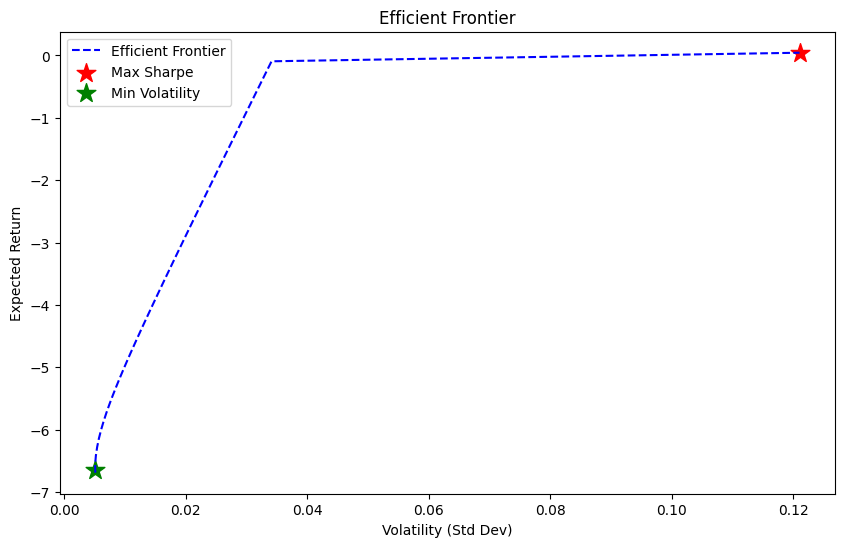


✅ Maximum Sharpe Portfolio:
  Asset        Weight
0  TSLA  0.000000e+00
1   SPY  1.000000e+00
2   BND  3.222961e-11

Expected Annual Return: 4.44%
Expected Annual Volatility: 12.11%
Sharpe Ratio: 0.37

✅ Minimum Volatility Portfolio:
  Asset        Weight
0  TSLA  9.941575e-01
1   SPY  5.842516e-03
2   BND  1.695170e-19

Expected Annual Return: -665.17%
Expected Annual Volatility: 0.51%
Sharpe Ratio: -1310.65


In [10]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))  # ensure parent folder is in path



# portfolio_optimization.ipynb (Single Cell)

# -----------------------------
# Task 4: Portfolio Optimization using MPT
# -----------------------------

# 1️⃣ Import libraries
import pandas as pd
import numpy as np
from src import portfolio
import matplotlib.pyplot as plt

# -----------------------------
# 2️⃣ Load Forecasted TSLA Returns and Historical SPY/BND Returns
# -----------------------------
tsla_forecast = pd.read_csv('../data/processed/TSLA_forecasted_6mo.csv', parse_dates=['Date'])
spy = pd.read_csv('../data/processed/SPY_cleaned.csv', parse_dates=['Date'])
bnd = pd.read_csv('../data/processed/BND_cleaned.csv', parse_dates=['Date'])

# Compute daily returns for SPY and BND
spy['Return'] = spy['Close'].pct_change()
bnd['Return'] = bnd['Close'].pct_change()

# Align dates for all three assets
returns_df = pd.DataFrame({
    'TSLA': tsla_forecast['Forecasted_Return'],
    'SPY': spy['Return'].reindex(tsla_forecast.index),
    'BND': bnd['Return'].reindex(tsla_forecast.index)
})

# Drop NaNs
returns_df.dropna(inplace=True)

# -----------------------------
# 3️⃣ Compute Expected Returns (Annualized)
# -----------------------------
expected_returns = pd.Series({
    'TSLA': returns_df['TSLA'].mean() * 252,
    'SPY': returns_df['SPY'].mean() * 252,
    'BND': returns_df['BND'].mean() * 252
})

print("Expected Returns (annualized):")
print(expected_returns)

# -----------------------------
# 4️⃣ Compute Covariance Matrix (Annualized)
# -----------------------------
cov_matrix = portfolio.compute_covariance_matrix(returns_df)
print("\nCovariance Matrix (annualized):")
print(cov_matrix)

# -----------------------------
# 5️⃣ Optimize Key Portfolios
# -----------------------------
# Max Sharpe
max_sharpe_port = portfolio.optimize_portfolio(expected_returns.values, cov_matrix.values, method='sharpe')

# Min Volatility
min_vol_port = portfolio.optimize_portfolio(expected_returns.values, cov_matrix.values, method='vol')

# -----------------------------
# 6️⃣ Generate Efficient Frontier
# -----------------------------
vols, rets, sharpes, weights_list = portfolio.efficient_frontier(expected_returns.values, cov_matrix.values, points=50)

# -----------------------------
# 7️⃣ Plot Efficient Frontier
# -----------------------------
portfolio.plot_efficient_frontier(vols, rets, sharpes, max_sharpe_port, min_vol_port, save_path='../figures/efficient_frontier.png')

# -----------------------------
# 8️⃣ Display Portfolio Recommendations
# -----------------------------
def display_portfolio(portfolio_dict, assets):
    w = portfolio_dict['weights']
    r = portfolio_dict['return']
    v = portfolio_dict['volatility']
    s = portfolio_dict['sharpe']
    df = pd.DataFrame({'Asset': assets, 'Weight': w})
    print(df)
    print(f"\nExpected Annual Return: {r:.2%}")
    print(f"Expected Annual Volatility: {v:.2%}")
    print(f"Sharpe Ratio: {s:.2f}")

print("\n✅ Maximum Sharpe Portfolio:")
display_portfolio(max_sharpe_port, returns_df.columns)

print("\n✅ Minimum Volatility Portfolio:")
display_portfolio(min_vol_port, returns_df.columns)


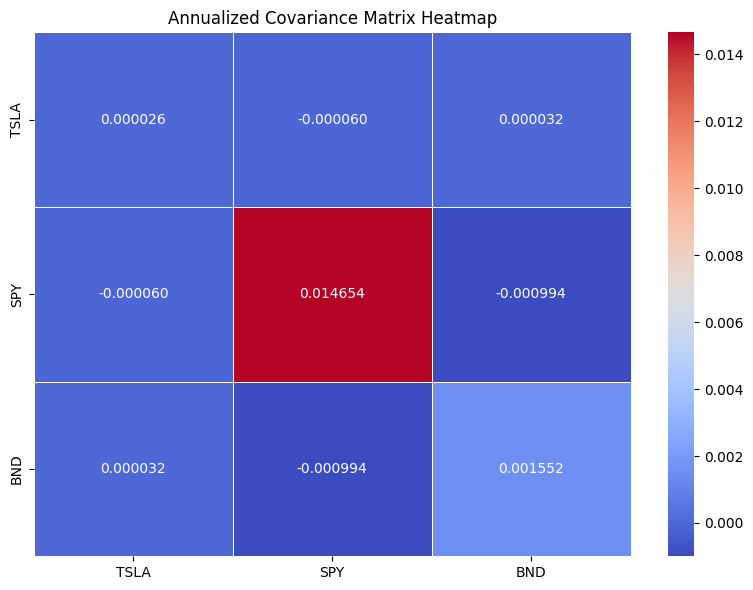

In [11]:
# Covariance Heatmap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Your annualized covariance matrix
cov_matrix_annualized = pd.DataFrame({
    "TSLA": [0.000026, -0.000060, 0.000032],
    "SPY": [-0.000060, 0.014654, -0.000994],
    "BND": [0.000032, -0.000994, 0.001552]
}, index=["TSLA", "SPY", "BND"])

plt.figure(figsize=(8, 6))
sns.heatmap(cov_matrix_annualized, annot=True, fmt=".6f", cmap="coolwarm", linewidths=0.5)
plt.title("Annualized Covariance Matrix Heatmap")
plt.tight_layout()

# Save figure to figures folder
plt.savefig("../figures/covariance_heatmap.png", dpi=300)
plt.show()
